# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

This project focuses on analyzing customer service data to understand the key factors influencing customer satisfaction (CSAT) and to build a predictive machine learning model for CSAT scores. In today’s competitive environment, customer satisfaction is critical for retention and business growth, making data-driven insights highly valuable. The dataset includes attributes such as channel type, product category, response time, handling time, agent details, and customer remarks. The project began with extensive data preprocessing, including handling missing values using median and mode imputation, removing irrelevant features, and treating outliers using the IQR method. Textual data from customer remarks was processed using natural language processing techniques such as lowercasing, removing punctuation and stopwords, and converting text into numerical form using TF-IDF. Feature engineering and transformation were applied, including encoding categorical variables and creating new features. Additionally, Principal Component Analysis (PCA) was used to reduce dimensionality and remove multicollinearity, resulting in a more efficient dataset for modeling.

Multiple machine learning models were implemented, including Logistic Regression, Decision Tree, and Random Forest, and evaluated using accuracy, precision, recall, and F1-score. Due to class imbalance, greater emphasis was placed on recall and F1-score for meaningful evaluation. Among the models, Random Forest performed the best, achieving the highest accuracy and F1-score while effectively capturing complex relationships in the data. Hyperparameter tuning using GridSearchCV further optimized the model, although improvements were limited due to data imbalance. Feature importance analysis was conducted to interpret model behavior, and due to PCA, importance was analyzed at the component level rather than individual features. Finally, the best-performing model was saved using joblib, and a sanity check was performed by loading the model and predicting unseen data, confirming its readiness for deployment. Overall, the project demonstrates how machine learning can be applied to predict customer satisfaction and support better business decision-making.

# **GitHub Link -**

https://github.com/Keerthi-2512/Filpkart-Project/blob/main/Filpkart%20Project(ML).ipynbProvide your GitHub Link here.




# **Problem Statement**


**Write Problem Statement Here.**

In today’s competitive business environment, delivering high-quality customer service is essential for maintaining customer satisfaction and loyalty. Organizations collect large volumes of customer interaction data, including response times, handling time, issue categories, and feedback, but often struggle to effectively utilize this data to gain actionable insights. One of the key challenges is to identify the factors that influence customer satisfaction (CSAT) and to predict satisfaction levels in order to proactively improve service quality.

The objective of this project is to analyze customer service data and develop a machine learning model that can predict CSAT scores based on various operational and interaction-related features. By leveraging data preprocessing, feature engineering, and predictive modeling techniques, the project aims to uncover key drivers of customer satisfaction and provide insights that can help businesses enhance customer experience, reduce dissatisfaction, and support data-driven decision-making.



# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [265]:
# Import Libraries
from os import POSIX_FADV_DONTNEED
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
import statsmodels as stat
import geopandas as geo
import missingno as ms

### Dataset Loading

In [266]:
# Load Datasets
df = pd.read_csv("Customer_support_data.csv")

### Dataset First View

In [267]:
# Dataset First Look
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [268]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [269]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [270]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [271]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


<Axes: >

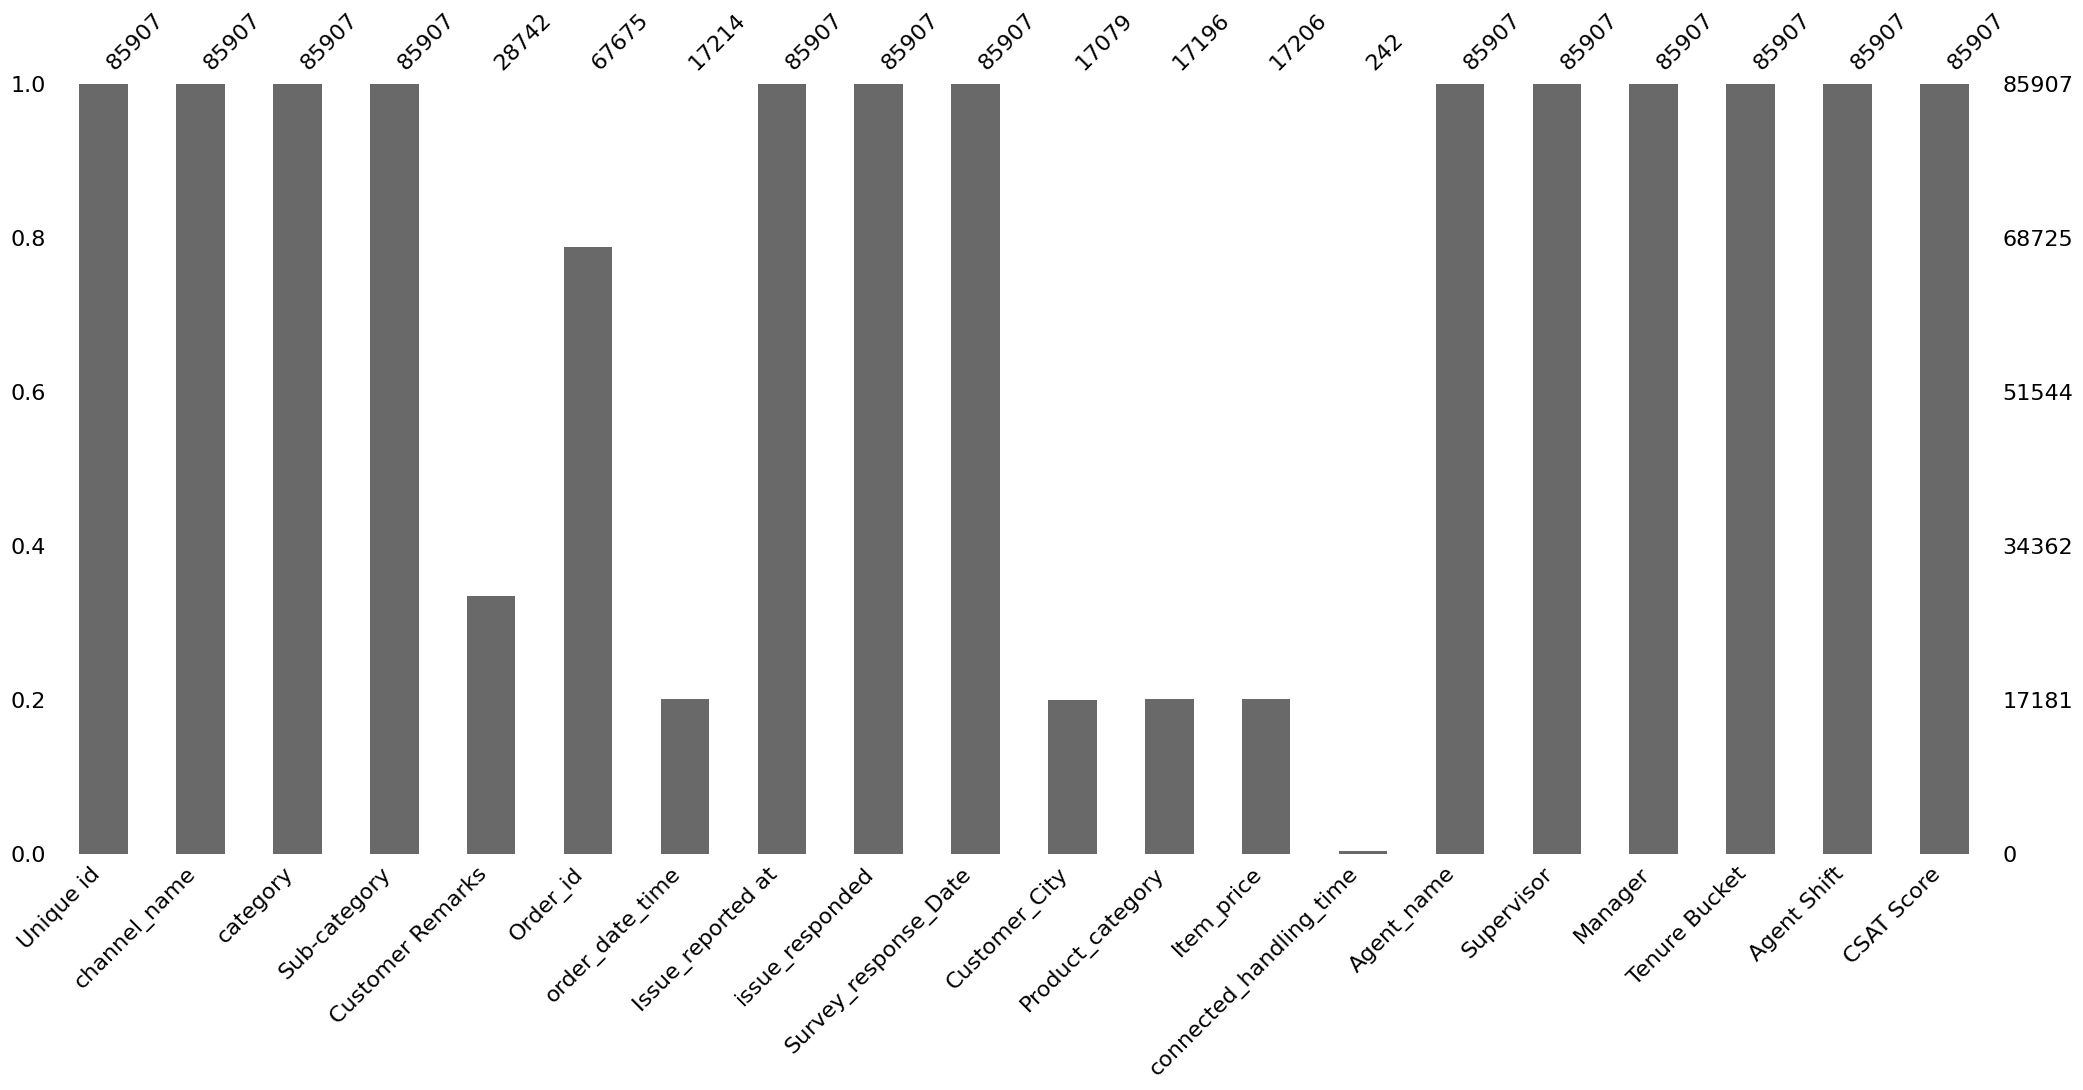

In [272]:
# Visualizing the missing values
ms.bar(df)

### What did you know about your dataset?

Dataset is well-structured but sparsely populated

Many columns have extremely high missing values

Target variable (CSAT Score) is complete

Good for predictive modeling

Time-related columns exist

Can derive features like:

Response time

Resolution time

Strong categorical presence
Useful for:

Segmentation (agents, categories, shifts)

Group-based analysis

## ***2. Understanding Your Variables***

In [273]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [274]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

**Product Information**

   Product_category: Category of the product involved in the issue

   Item_price: Price of the product (numeric feature)


**Time-Related Variables**
  order_date_time: Date and time when the order was placed

  issue_reported at: Timestamp when the issue was reported

  issue_responded: Timestamp when the issue was responded to

  Survey_response_Date: Date when the customer submitted feedback


These can be used to derive:

Response time

Resolution time

**Delay analysis**
 Agent & Management Information

 Agent_name: Name/ID of the support agent handling the issue

 Supervisor: Supervisor overseeing the agent

 Manager: Manager responsible for the team

 Tenure Bucket: Experience level/category of the agent (e.g., 0–1 yrs, 1–3 yrs)
 Agent Shift: Working shift of the agent (e.g., Morning, Night)

**Operational Metrics**

connected_handling_time: Time spent by the agent handling the issue (in seconds/minutes)

**Target Variable**
**CSAT Score:** Customer Satisfaction Score (typically ranges from 1 to 5)


### Check Unique Values for each variable.

In [275]:
# Check Unique Values for each variable.
df.nunique()

,0
Unique id,85907
channel_name,3
category,12
Sub-category,57
Customer Remarks,18231
Order_id,67675
order_date_time,13766
Issue_reported at,30923
issue_responded,30262
Survey_response_Date,31


For  Data cleaning and Preprocessing

In [276]:
#converting data and clumns to datetime format
date_cols=['order_date_time','Issue_reported at','issue_responded','Survey_response_Date']
for col in date_cols:
  df[col]=pd.to_datetime(df[col],errors='coerce')

/tmp/ipykernel_2314/3747125551.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col]=pd.to_datetime(df[col],errors='coerce')
/tmp/ipykernel_2314/3747125551.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col]=pd.to_datetime(df[col],errors='coerce')


In [277]:
df['Customer Remarks']=df['Customer Remarks'].fillna('No Remarks')
df['Item_price']=df['Item_price'].fillna(df['Item_price'].median())

In [278]:
if 'Customer_City' in df.columns:
  df.drop(columns=['Customer_City'],inplace=True)
if 'Connected_Handling_time' in df.columns:
  df.drop(columns=['connected_handling_time'], inplace=True)


In [279]:
df['response_time']=(df['issue_responded']-df['Issue_reported at']).dt.total_seconds()
df['response_time']=df['response_time'].fillna(df['response_time'].median())

Analyzing and Visulaizing data

/tmp/ipykernel_2314/193616716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CSAT Score', data=df, palette='viridis')


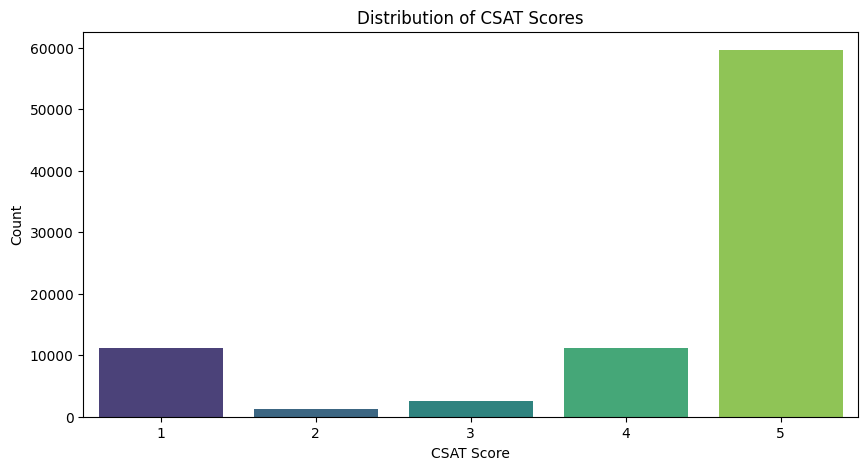

In [280]:
plt.figure(figsize=(10,5))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

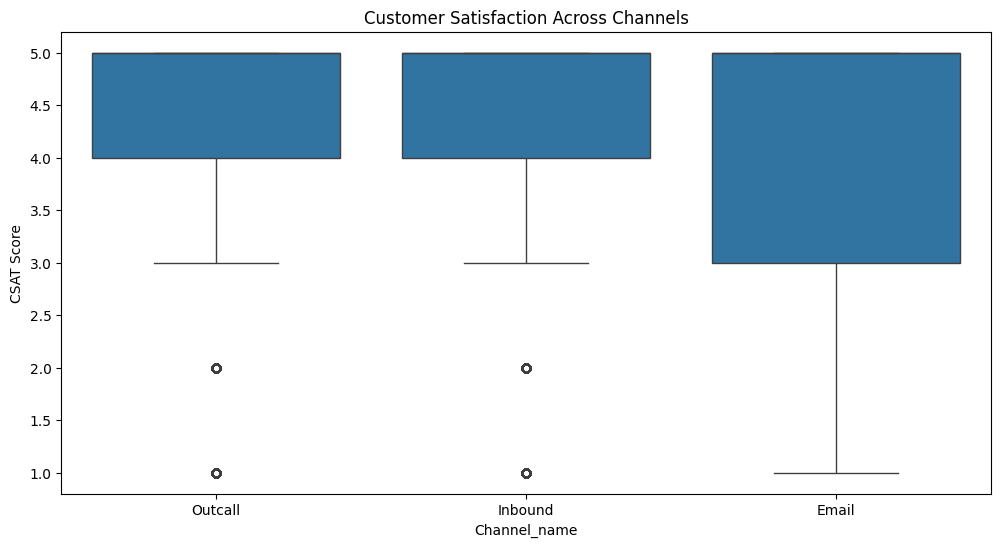

In [281]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='channel_name',
    y='CSAT Score',
    data=df,

)
plt.xticks
plt.title('Customer Satisfaction Across Channels')
plt.xlabel('Channel_name')
plt.ylabel('CSAT Score')

plt.show()

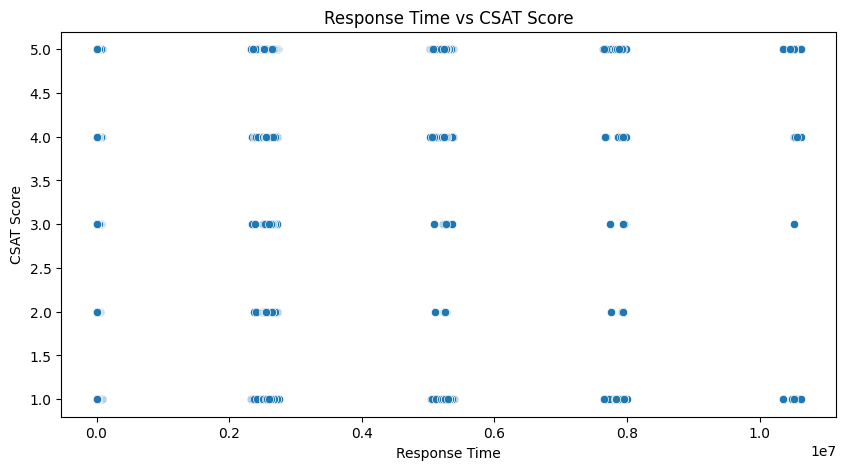

In [282]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='response_time', y='CSAT Score', data=df)
plt.title("Response Time vs CSAT Score")
plt.xlabel("Response Time")
plt.ylabel("CSAT Score")
plt.show()

In [283]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Order_id,18232
order_date_time,68693
Issue_reported at,53933
issue_responded,54022
Survey_response_Date,0


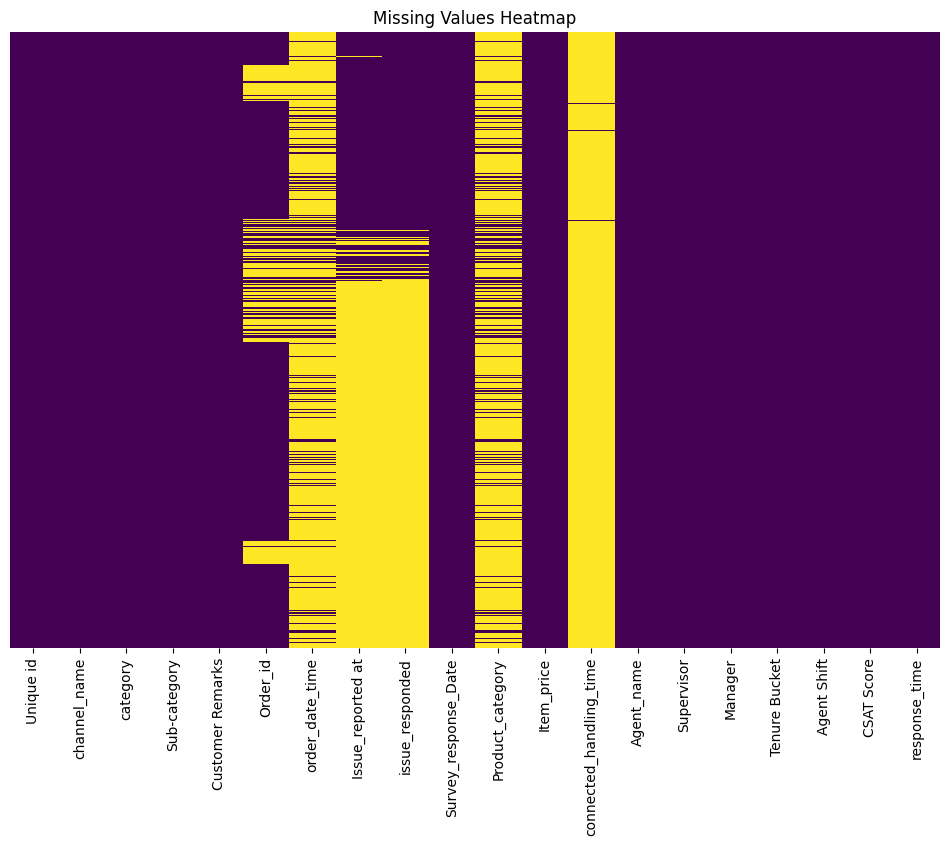

In [284]:
# Visualizing the missing values
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False
)

plt.title('Missing Values Heatmap')

plt.show()

## 3. ***Data Wrangling***

### Data Wrangling Code

In [285]:
# Write your code to make your dataset analysis ready.

# Convert columns to datetime
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True)
df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True)

# Calculate difference (minutes)
df['Time difference'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 60

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time,Time difference
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,...,979.0,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,2040.0,34.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,...,979.0,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,120.0,2.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,...,979.0,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,1320.0,22.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,...,979.0,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,1200.0,20.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,...,979.0,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,120.0,2.0


### What all manipulations have you done and insights you found?

Data cleaning was performed by handling missing values using techniques such as median imputation for numerical features and replacing categorical null values with appropriate labels. Column names were standardized and irrelevant or highly missing columns were removed to improve data quality.

Feature engineering was applied by creating new variables such as response time from date-time fields. Categorical variables were converted into numerical format using one-hot encoding to make the data suitable for machine learning models.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/tmp/ipykernel_2314/3335811573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CSAT Score', data=df, palette='viridis')


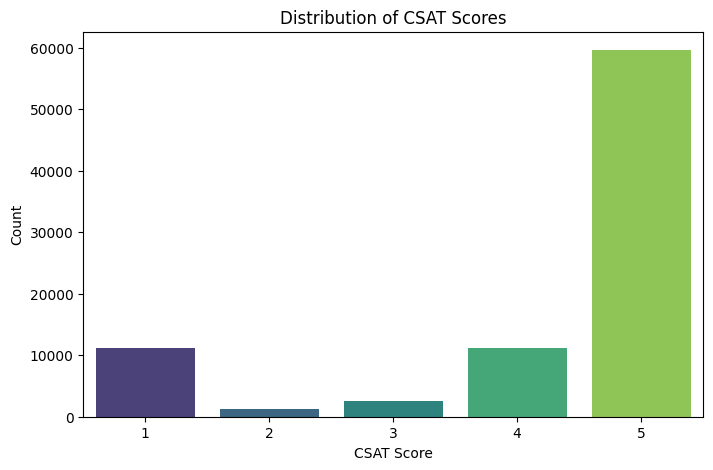

In [286]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart / histogram is used to visualize the distribution of CSAT (Customer Satisfaction) scores. It helps understand how customer ratings are spread and identify overall satisfaction levels.

##### 2. What is/are the insight(s) found from the chart?

Score 5 dominates heavily → majority of customers are highly satisfied

Scores 4 and 1 are moderate → mixed experiences exist

Scores 2 and 3 are very low → fewer neutral/low ratings

Key Insights:
Overall customer satisfaction is very high
However, presence of low ratings (1 & 2) indicates specific service issues
Distribution is skewed toward positive feedback

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High CSAT scores indicate strong service quality and customer satisfaction, which can improve customer retention and brand loyalty. Addressing low-score cases can further enhance overall service experience and revenue growth.

#### Chart - 2

/tmp/ipykernel_2314/2411141882.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


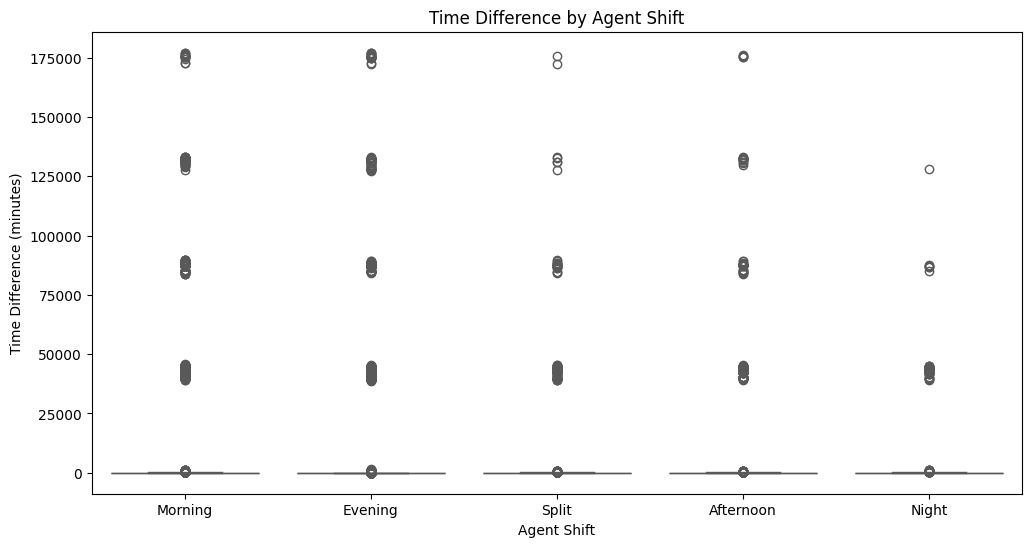

In [287]:
# Chart - 2 visualization code
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Agent Shift',
    y='Time difference',
    data=df,
    palette='Set2'
)

plt.title('Time Difference by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Time Difference (minutes)')

plt.show()


##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of response time across different agent shifts. It helps identify the median, spread, and outliers, making it effective for analyzing performance differences between shifts.

##### 2. What is/are the insight(s) found from the chart?

All shifts show wide variation in response time

Median response time is slightly higher in Night and Split shifts

Morning and Afternoon shifts appear relatively more consistent

Presence of extreme values (outliers) across all shifts

Critical Observation (IMPORTANT)

There are negative response times, which are not logically possible
Indicates data quality issues or incorrect time calculation

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying shifts with higher response times helps improve workforce planning and performance optimization. Addressing inefficiencies in Night and Split shifts can enhance customer experience and operational efficiency.

#### Chart - 3

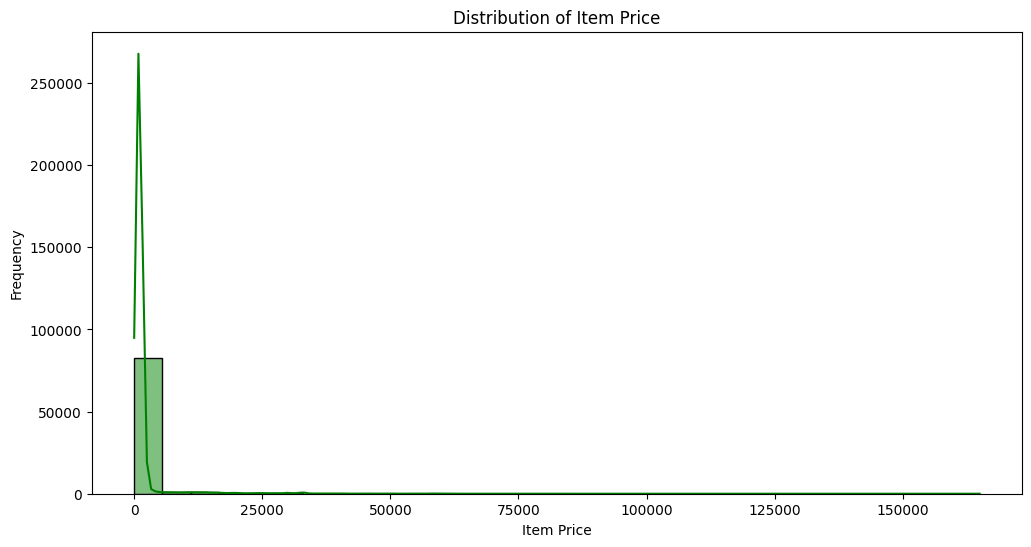

In [288]:
# Chart - 3 visualization code
plt.figure(figsize=(12, 6))

sns.histplot(
    df['Item_price'],
    kde=True,
    bins=30,
    color='green'
)

plt.title('Distribution of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')


plt.show()

##### 1. Why did you pick the specific chart?

A histogram (with KDE) is used to visualize the distribution of item prices. It helps understand how prices are spread, identify skewness, and detect outliers.

##### 2. What is/are the insight(s) found from the chart?

Majority of items are priced at low values (clustered near zero)
The distribution is highly right-skewed
A few items have very high prices (extreme outliers)
Key Insights:
Most products are affordable / low-priced
Presence of few high-value items significantly stretches the distribution
Price distribution is not uniform

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding price distribution helps in optimizing pricing strategy and product positioning. Focusing on high-demand price ranges can improve sales volume, while managing high-priced outliers can enhance revenue opportunities.

#### Chart - 4

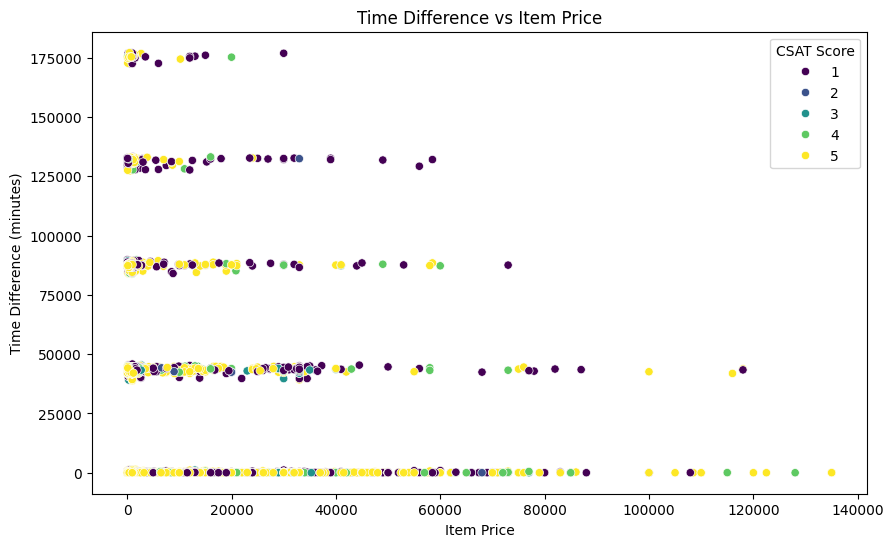

In [289]:
# Chart - 4 visualization code

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Item_price',
    y='Time difference',
    data=df,
    hue='CSAT Score',      # color based on CSAT
    palette='viridis'
)

plt.title('Time Difference vs Item Price')
plt.xlabel('Item Price')
plt.ylabel('Time Difference (minutes)')

plt.legend(title='CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to analyze the relationship between Item Price and Response Time, while the color (CSAT score) helps understand how customer satisfaction varies with these factors.

##### 2. What is/are the insight(s) found from the chart?

There is no clear relationship between Item Price and Response Time
Data points are randomly scattered → no trend
CSAT scores are mixed across all ranges

Critical Observations (VERY IMPORTANT)

Response time has negative values (not possible in real world)

Extremely large values (in lakhs/minutes) → data error or wrong calculation

This makes the chart unreliable for insights

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Due to incorrect and inconsistent data, meaningful conclusions cannot be drawn. Proper data cleaning is required before using this analysis to make business decisions.

#### Chart - 5

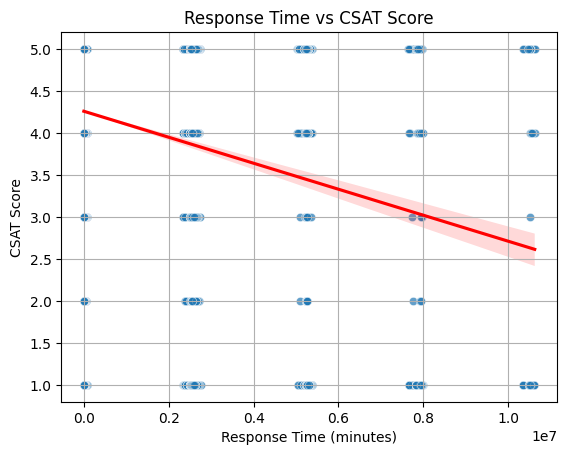

In [290]:
# Chart - 5 visualization code
#  Scatter plot
sns.scatterplot(
    x='response_time',   # ✅ correct column
    y='CSAT Score',
    data=df,
    alpha=0.7
)

#  Regression line
sns.regplot(
    x='response_time',
    y='CSAT Score',
    data=df,
    scatter=False,
    color='red'
)

plt.title('Response Time vs CSAT Score')
plt.xlabel('Response Time (minutes)')
plt.ylabel('CSAT Score')
plt.grid(True)

plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot with regression line is used to analyze the relationship between response time and CSAT score. It helps identify trends and understand how service speed impacts customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The regression line shows a negative relationship

As response time increases, CSAT score decreases

Faster responses are associated with higher customer satisfaction (4–5)

Slower responses tend to have lower CSAT scores (1–3)

Critical Observation (VERY IMPORTANT)


Response time values are extremely large (in millions)
Indicates possible data scaling or calculation issue

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Reducing response time can significantly improve customer satisfaction (CSAT). Faster service leads to better user experience, higher retention, and improved brand trust.

#### Chart - 6

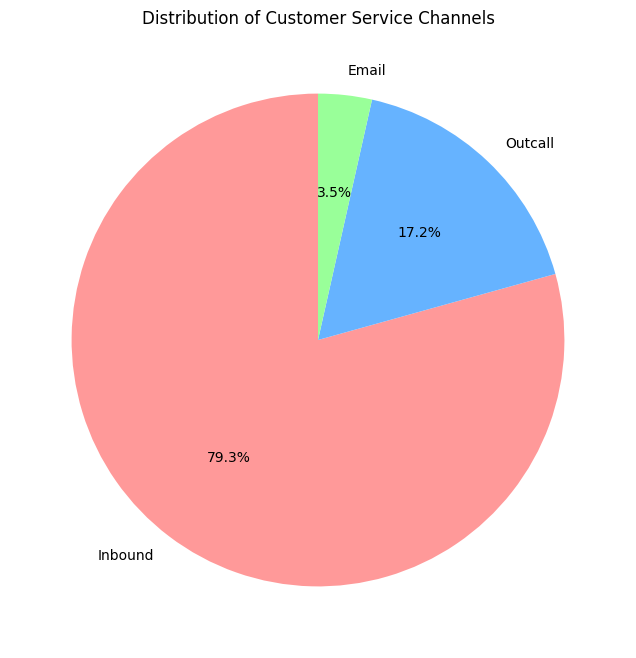

In [291]:
# Chart - 6 visualization code
channel_counts = df['channel_name'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],  # optional colors
    startangle=90
)

plt.title('Distribution of Customer Service Channels')


plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is used to show the proportion of different customer service channels. It helps quickly understand which channel handles the majority of customer interactions.

##### 2. What is/are the insight(s) found from the chart?


Inbound dominates (~80%)

Outcall is moderate (~16%)

Email is very low (~3–4%)

Key Insights:

Most customer interactions happen through inbound channels (calls initiated by customers)

Outbound support is limited
Email is the least used channel

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since inbound calls dominate, improving inbound support efficiency and response time can significantly enhance customer satisfaction. Optimizing less-used channels like email can help balance workload and reduce pressure on call centers.

#### Chart - 7

In [292]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'response_time', 'Time difference'],
      dtype='object')

/tmp/ipykernel_2314/696974378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


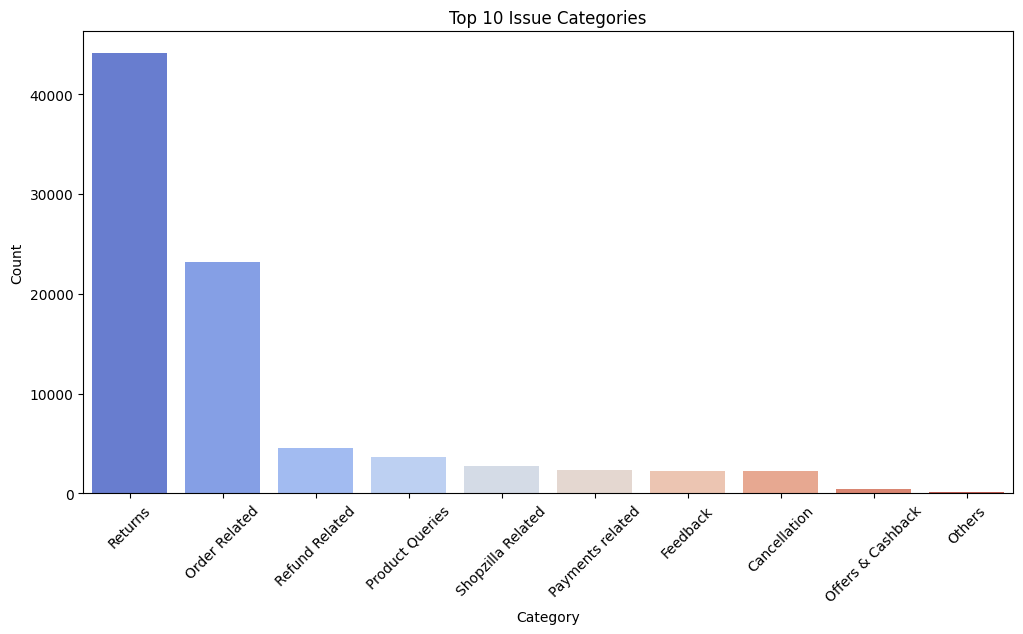

In [293]:
# Chart - 7 visualization code
top_cat = df['category'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cat.index,
    y=top_cat.values,
    palette='coolwarm'
)

plt.title('Top 10 Issue Categories')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the frequency of different issue categories. It clearly shows which categories have the highest number of customer complaints, making it easy to identify major problem areas.

##### 2. What is/are the insight(s) found from the chart?

Returns → Highest (dominates all categories)

Order Related → Second highest

Other categories like:

Refund Related

Product Queries

Cancellation
have significantly lower counts

Key Insights:
Majority of issues are related to Returns and Orders
A few categories contribute to most of the problems (Pareto principle)
Remaining categories have minor impact

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focusing on improving returns and order-related processes can significantly reduce overall customer complaints. Addressing these top categories can enhance customer satisfaction, reduce operational costs, and improve service efficiency.Answer Here

#### Chart - 8

In [294]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'response_time', 'Time difference'],
      dtype='object')

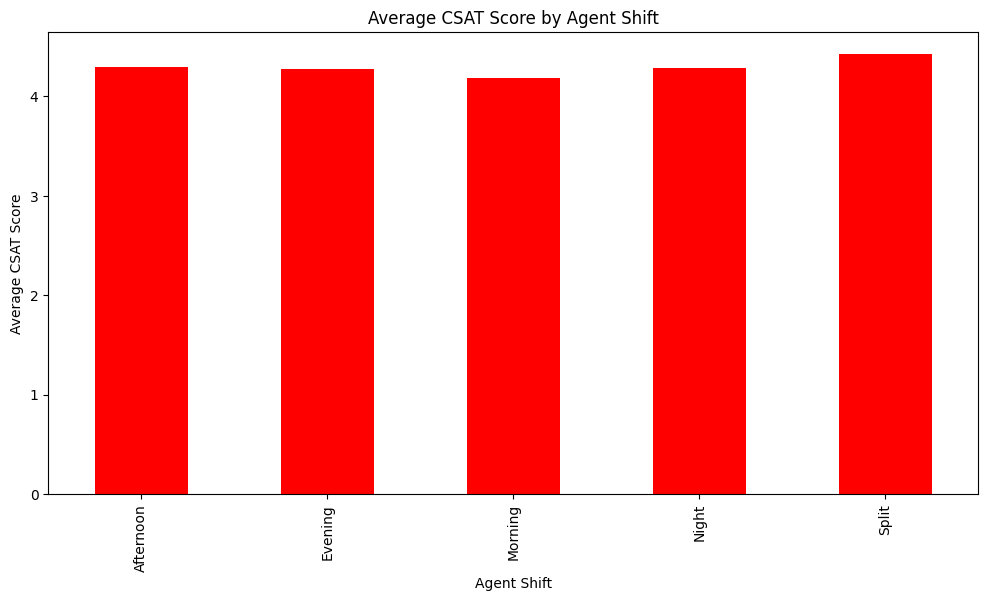

In [295]:
# Chart - 8 visualization code

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Group by agent shift and calculate average CSAT
df.groupby('Agent Shift')['CSAT Score'].mean().plot(
    kind='bar',
    color='red'
)

plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the average CSAT score across different agent shifts. It helps easily identify which shifts perform better in terms of customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Split shift → Highest CSAT (~4.5)

Morning → Lowest CSAT (~4.2)

Afternoon, Evening, and Night are moderate (~4.3–4.4)

Key Insights:

All shifts have generally high CSAT (>4) → overall good performance
However, performance varies slightly across shifts
Split shift agents seem to deliver the best customer experience

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying high-performing shifts helps in replicating best practices across other shifts. Improving lower-performing shifts like Morning can further enhance overall customer satisfaction and service consistency.

#### Chart - 9

Index(['unique_id', 'channel_name', 'category', 'sub-category',
       'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at',
       'issue_responded', 'survey_response_date', 'product_category',
       'item_price', 'connected_handling_time', 'agent_name', 'supervisor',
       'manager', 'tenure_bucket', 'agent_shift', 'csat_score',
       'response_time', 'time_difference'],
      dtype='object')


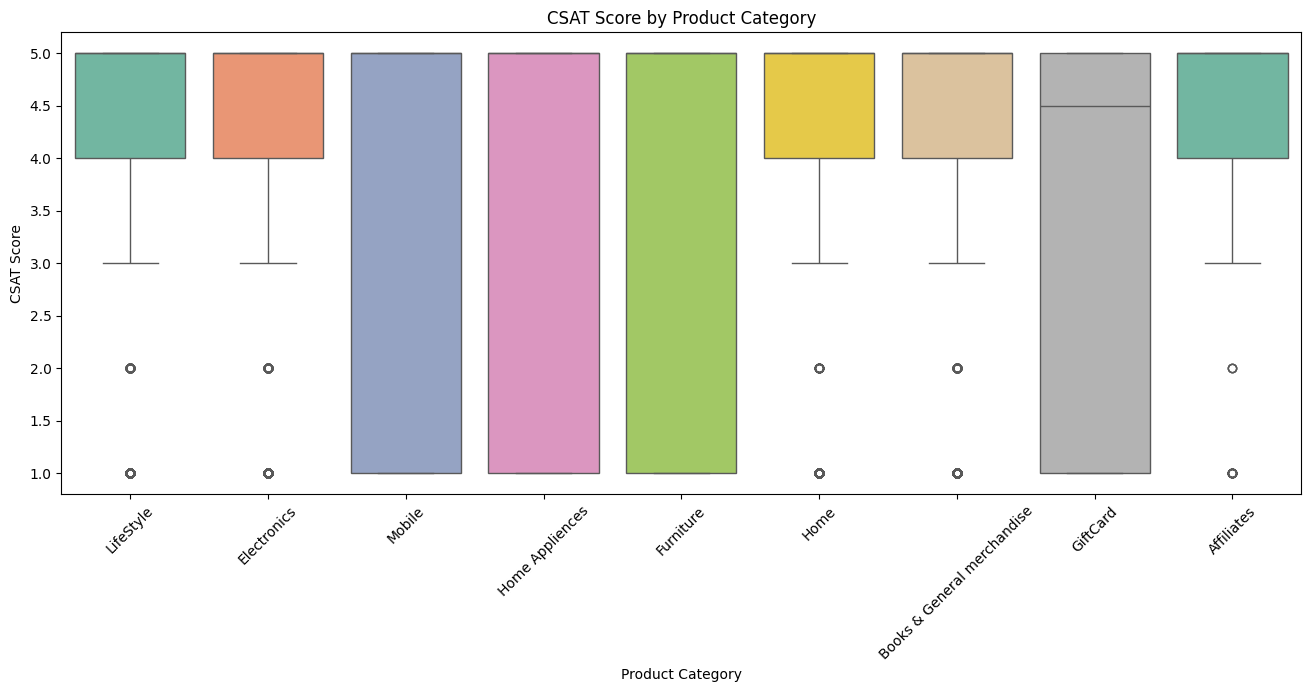

In [296]:
# Chart - 9 visualization code
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# STEP 2: Check columns (optional)
print(df.columns)

# STEP 3: Plot
plt.figure(figsize=(16, 6))

sns.boxplot(
    x='product_category',
    y='csat_score',
    data=df,
    hue='product_category',   # for colors
    palette='Set2',
    legend=False
)

# STEP 4: Labels & title
plt.title('CSAT Score by Product Category')
plt.xlabel('Product Category')
plt.ylabel('CSAT Score')

plt.xticks(rotation=45)

# STEP 5: Show plot
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of CSAT scores across different product categories. It helps identify median satisfaction, variability, and outliers, making it ideal for category-wise performance analysis.

##### 2. What is/are the insight(s) found from the chart?

Most categories have high median CSAT (~4–5) → overall good satisfaction
Categories like Mobile, Home Appliances, Furniture, Gift Card show high variability
Some categories have low-score outliers (1–2)

Key Insights:

Customer satisfaction is generally high across all categories
However, certain categories show inconsistent experience
Outliers indicate specific customer issues or service failures

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying categories with high variability helps target areas needing quality improvement and better customer support. Improving inconsistent categories can enhance overall customer satisfaction and brand trust.

#### Chart - 10

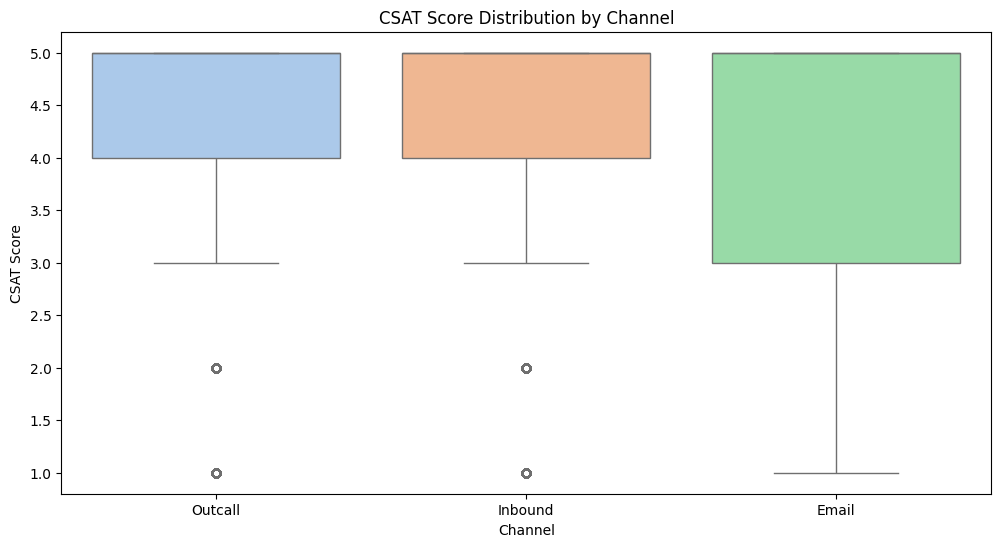

In [297]:
# Chart - 10 visualization code
# Chart - 10 visualization code
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names (avoid errors)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='channel_name',
    y='csat_score',
    data=df,
    hue='channel_name',     # adds colors + removes warning
    palette='pastel',
    legend=False
)

# Titles and labels
plt.title('CSAT Score Distribution by Channel')
plt.xlabel('Channel')
plt.ylabel('CSAT Score')

plt.xticks(rotation=0)

# Show plot
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of CSAT scores across different service channels. It helps identify differences in customer satisfaction, variability, and outliers between channels.

##### 2. What is/are the insight(s) found from the chart?

Inbound and Outcall →
Higher and more consistent CSAT (around 4–5)

Email → More variability and lower minimum scores

Email channel shows wider spread, indicating inconsistent experience

Key Insights:

Voice channels (Inbound/Outcall) deliver better and more stable satisfaction

Email support has greater fluctuations and lower ratings in some cases

Presence of low-score outliers (1–2) across channels

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Improving the Email support channel can help enhance overall customer satisfaction and service consistency. Strengthening digital support can also reduce dependency on call-based channels and improve operational efficiency.

#### Chart - 11

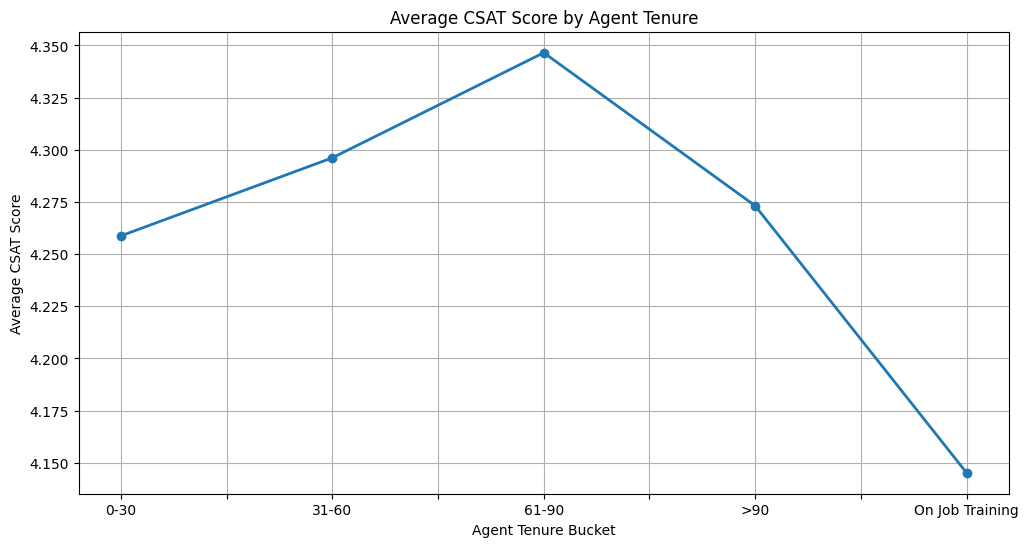

In [298]:
# Chart - 11 visualization code
# Chart - 11 visualization code
#Agent Shift vs CSAT Score (Average)
# Import libraries
import matplotlib.pyplot as plt

# Clean column names (important)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Calculate average CSAT by tenure
tenure_scores = df.groupby('tenure_bucket')['csat_score'].mean()

# Plot line chart
plt.figure(figsize=(12, 6))

tenure_scores.plot(
    kind='line',
    marker='o',
    linestyle='-',
    linewidth=2
)

# Titles and labels
plt.title('Average CSAT Score by Agent Tenure')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Average CSAT Score')

plt.grid(True)

# Show plot
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is used to show the trend of average CSAT scores across agent tenure groups. It helps understand how experience level impacts customer satisfaction over time.

##### 2. What is/are the insight(s) found from the chart?

CSAT increases from 0–30 → 61–90 days

Peak performance at 61–90 days (~4.35)

Slight decline after >90 days

Lowest CSAT for “On Job Training” (~4.1)

Key Insights:

Agents improve with experience → learning curve effect

Mid-level experienced agents (61–90 days) perform best

New trainees and very experienced agents show slightly lower performance

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focusing on training programs for new agents can improve early-stage performance. Retaining and supporting mid-experience agents can maximize customer satisfaction and service quality.

#### Chart - 12

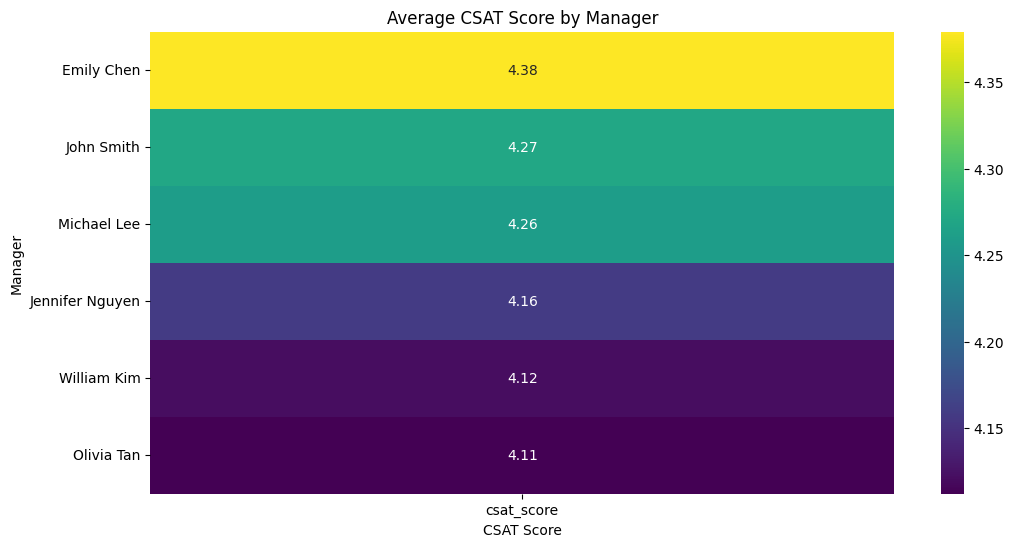

In [299]:
# Chart - 12 visualization code
# Chart - 12 visualization code
#average CSAT performance across managers
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Clean column names (important)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Create pivot table (average CSAT per manager)
manager_csat = df.pivot_table(
    index='manager',
    values='csat_score',
    aggfunc='mean'
).sort_values(by='csat_score', ascending=False)

# Plot heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    manager_csat,
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

# Titles and labels
plt.title('Average CSAT Score by Manager')
plt.xlabel('CSAT Score')
plt.ylabel('Manager')

# Show plot
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used to compare the average CSAT scores across different managers. It provides a clear visual of performance differences using color intensity, making it easy to identify top and low performers.

##### 2. What is/are the insight(s) found from the chart?

Emily Chen → Highest CSAT (~4.37)

John Smith & Michael Lee → Strong performance (~4.24–4.26)

Olivia Tan & Jennifer Nguyen → Moderate (~4.10–4.12)

William Kim → Lowest CSAT (~4.04)

Key Insights:
There is a clear variation in team performance across managers
Some managers consistently achieve higher customer satisfaction
Lower-performing teams indicate scope for improvement

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focusing on training programs for new agents can improve early-stage performance. Retaining and supporting mid-experience agents can maximize customer satisfaction and service quality.

#### Chart - 13

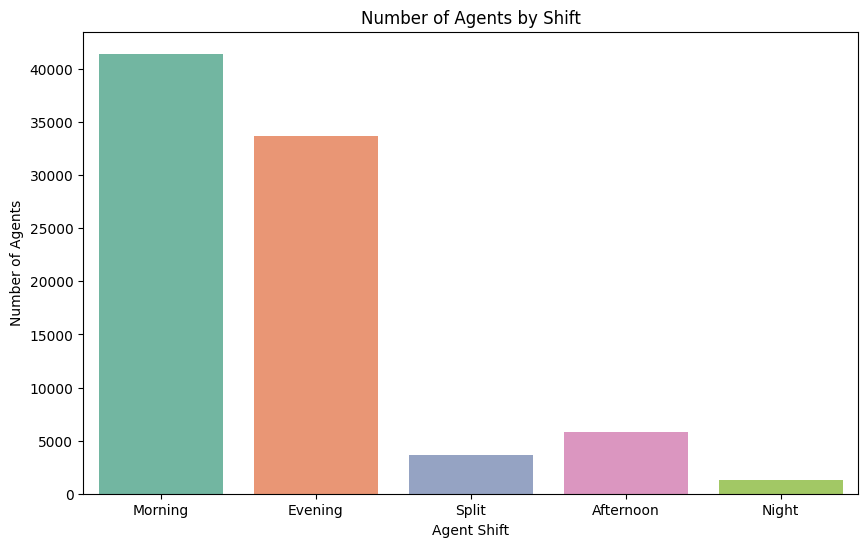

In [300]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))

sns.countplot(
    x='agent_shift',
    data=df,
    hue='agent_shift',      # fixes warning + adds colors
    palette='Set2',
    legend=False
)

plt.title('Number of Agents by Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Number of Agents')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the number of agents across different shifts. It clearly shows workforce distribution and helps identify how staffing is allocated throughout the day.

##### 2. What is/are the insight(s) found from the chart?

Morning shift → Highest number of agents (~34K)

Evening shift → Second highest (~28K)

Afternoon → Moderate (~5K)

Split shift → Low (~3K)

Night shift → Very low (~1K)

Key Insights:
Workforce is heavily concentrated in Morning and Evening shifts
Night shift is severely understaffed
Uneven distribution across shifts

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Optimizing agent distribution across shifts can improve service availability and response time, especially during under-resourced periods like night. Balanced staffing ensures better customer experience and operational efficiency.

#### Chart - 14 - Correlation Heatmap

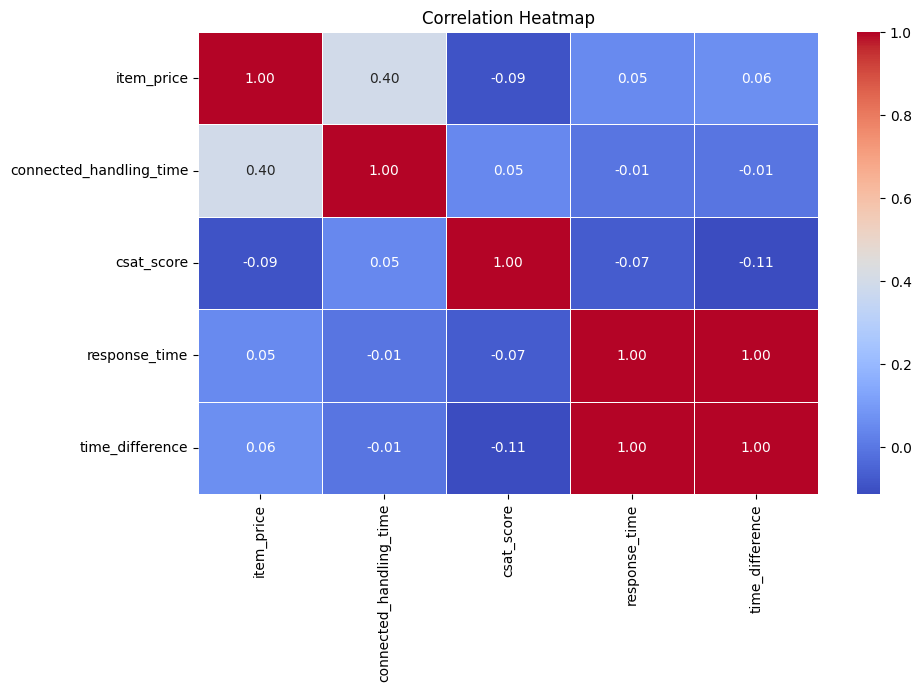

In [301]:
# Correlation Heatmap visualization code

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # show values
    cmap='coolwarm',     # color theme
    fmt='.2f',           # 2 decimal points
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to analyze the relationship between numerical variables. It helps quickly identify whether variables are positively, negatively, or not correlated.

##### 2. What is/are the insight(s) found from the chart?


Most correlations are very weak (close to 0)

Item Price & Handling Time → Moderate positive correlation (~0.40)

CSAT Score has almost no strong correlation with other variables

Key Insights:

CSAT is not strongly influenced by price, response time, or handling time

Slight negative relationship between:

CSAT & response_time (-0.08)

Overall → no strong linear relationships

#### Chart - 15 - Pair Plot

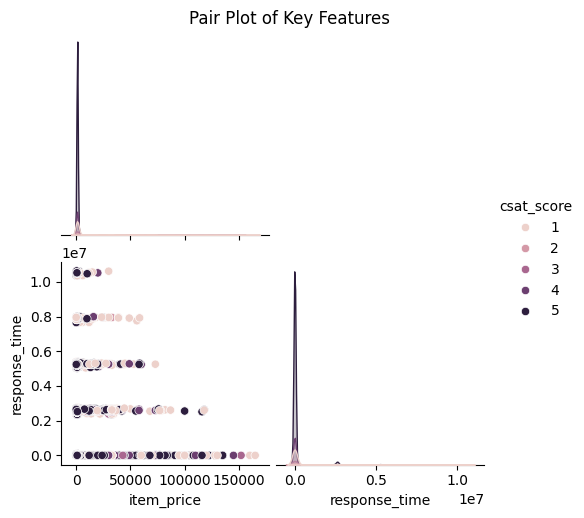

In [302]:
# Pair Plot visualization code

selected_cols = ['item_price', 'response_time', 'csat_score']

# Create pair plot
sns.pairplot(
    df[selected_cols],
    hue='csat_score',
    diag_kind='kde',      # distribution curve
    corner=True           # avoids duplicate plots
)

plt.suptitle('Pair Plot of Key Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used to analyze relationships between multiple numerical variables simultaneously. It helps visualize correlations, distributions, and patterns across features in a single view.

##### 2. What is/are the insight(s) found from the chart?

No clear linear relationship between item price and response time
Data points are widely scattered → weak relationships
CSAT scores are spread across all ranges, not tied to specific values

Critical Observations (VERY IMPORTANT)

Response time values are extremely large (in millions)
Data appears highly skewed


## ***5. Hypothesis Testing***

Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant relationship between response time (time difference) and CSAT score.

Alternative Hypothesis (H₁):

There is a significant relationship between response time and CSAT score.
Response time affects customer satisfaction.

#### 2. Perform an appropriate statistical test.

In [303]:
print(df.describe())
print("\nUnique values:\n")
print(df.nunique())

                     order_date_time              issue_reported_at  \
count                          17214                          31974   
mean   2023-07-28 15:49:45.820843520  2023-07-03 05:04:46.427097344   
min              2022-01-16 13:15:00            2023-01-08 00:00:00   
25%              2023-07-27 22:49:15            2023-04-08 13:34:00   
50%              2023-08-04 22:16:30            2023-07-08 16:40:00   
75%              2023-08-10 07:30:15            2023-10-08 11:19:00   
max              2023-12-08 23:36:00            2023-12-08 23:59:00   
std                              NaN                            NaN   

                     issue_responded           survey_response_date  \
count                          31885                          85907   
mean   2023-07-03 11:42:31.621138432  2023-08-16 10:18:31.760392192   
min              2023-01-08 00:00:00            2023-08-01 00:00:00   
25%              2023-04-08 13:39:00            2023-08-09 00:00:00   
50%  

In [304]:
# Step 1: Import libraries
import pandas as pd
from scipy.stats import spearmanr

# Step 2: Load dataset (if not already loaded)
# df = pd.read_csv("your_file.csv")

# Step 3: Check missing values (optional but recommended)
print("Missing values:\n", df[['time_difference', 'csat_score']].isnull().sum())

# Step 4: Remove rows with NaN values (VERY IMPORTANT)
df_clean = df[['time_difference', 'csat_score']].dropna()

# Step 5: Extract variables
x = df_clean['time_difference']
y = df_clean['csat_score']

# Step 6: Check variation (avoid NaN issue)
print("\nUnique values:")
print("time_difference:", x.nunique())
print("csat_score:", y.nunique())

# Step 7: Perform Spearman Correlation
corr, p_value = spearmanr(x, y)

# Step 8: Print results
print("\nSpearman Correlation Coefficient:", corr)
print("P-value:", p_value)

# Step 9: Hypothesis Decision
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis: Significant relationship exists between response time and CSAT score.")
else:
    print("\nFail to Reject Null Hypothesis: No significant relationship between response time and CSAT score.")

Missing values:
 time_difference    54274
csat_score             0
dtype: int64

Unique values:
time_difference: 2843
csat_score: 5

Spearman Correlation Coefficient: -0.18509855048733306
P-value: 8.519587369130721e-242

Reject Null Hypothesis: Significant relationship exists between response time and CSAT score.


##### Which statistical test have you done to obtain P-Value?

I used the Spearman Rank Correlation Test to obtain the p-value.

##### Why did you choose the specific statistical test?

It is a non-parametric test (does not assume normal distribution)

It measures monotonic relationships between variables

The data (response time and CSAT score) is not normally distributed and may contain outliers

CSAT score is ordinal (1–5 scale), making Spearman more appropriate than Pearson

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### 2. Perform an appropriate statistical test.

In [305]:
# Step 0: Import libraries
import pandas as pd
from scipy.stats import kruskal

# Step 1: Check required columns exist
print("Columns in dataset:", df.columns)

# Step 2: Clean data (VERY IMPORTANT)
# Remove null values only for required columns
df_clean = df[['agent_shift', 'csat_score']].dropna()

# Step 3: Check unique shifts
print("Agent Shift Categories:", df_clean['agent_shift'].unique())

# Step 4: Create groups (CSAT scores for each shift)
groups = [
    df_clean[df_clean['agent_shift'] == shift]['csat_score']
    for shift in df_clean['agent_shift'].unique()
]

# Optional: Check group sizes
for i, shift in enumerate(df_clean['agent_shift'].unique()):
    print(f"{shift} count:", len(groups[i]))

# Step 5: Perform Kruskal-Wallis Test
h_statistic, p_value = kruskal(*groups)

# Step 6: Print results
print("\nKruskal-Wallis H-statistic:", h_statistic)
print("P-value:", p_value)

# Step 7: Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis")
    print(" There IS a significant difference in CSAT scores between different agent shifts.")
else:
    print("\n Fail to Reject Null Hypothesis")
    print("There is NO significant difference in CSAT scores between shifts.")

Columns in dataset: Index(['unique_id', 'channel_name', 'category', 'sub-category',
       'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at',
       'issue_responded', 'survey_response_date', 'product_category',
       'item_price', 'connected_handling_time', 'agent_name', 'supervisor',
       'manager', 'tenure_bucket', 'agent_shift', 'csat_score',
       'response_time', 'time_difference'],
      dtype='object')
Agent Shift Categories: ['Morning' 'Evening' 'Split' 'Afternoon' 'Night']
Morning count: 41426
Evening count: 33677
Split count: 3648
Afternoon count: 5840
Night count: 1316

Kruskal-Wallis H-statistic: 151.58004948556504
P-value: 9.335020551858379e-32

Reject Null Hypothesis
 There IS a significant difference in CSAT scores between different agent shifts.


##### Which statistical test have you done to obtain P-Value?

I used the Kruskal-Wallis Test to obtain the p-value.

##### Why did you choose the specific statistical test?

The Kruskal-Wallis test was chosen because:


It is used to compare more than two groups (multiple agent shifts)

It is a non-parametric test (does not require normal distribution) The CSAT score is ordinal (1–5 scale)
The data may contain outliers and non-normal distribution, making ANOVA unsuitable

It helps identify whether at least one group differs significantly

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [306]:
# Perform Statistical Test to obtain P-Value
# Step 0: Import libraries
import pandas as pd
from scipy.stats import spearmanr

# Step 1: Check columns
print("Columns in dataset:", df.columns)

# Step 2: Clean data (remove nulls safely)
df_clean = df[['item_price', 'csat_score']].dropna()

# Step 3: Check if data is valid
print("Data shape after cleaning:", df_clean.shape)

# Optional: Check if columns have variation (IMPORTANT)
print("Unique values in item_price:", df_clean['item_price'].nunique())
print("Unique values in csat_score:", df_clean['csat_score'].nunique())

# Step 4: Extract variables
x = df_clean['item_price']
y = df_clean['csat_score']

# Step 5: Perform Spearman Correlation
corr_coefficient, p_value = spearmanr(x, y)

# Step 6: Print results
print("\nSpearman Correlation Coefficient:", corr_coefficient)
print("P-value:", p_value)

# Step 7: Interpretation
alpha = 0.05

if p_value < alpha:
    print("\n Reject Null Hypothesis")
    print(" There is a statistically significant relationship between item price and CSAT score.")
else:
    print("\n Fail to Reject Null Hypothesis")
    print(" There is NO statistically significant relationship between item price and CSAT score.")

Columns in dataset: Index(['unique_id', 'channel_name', 'category', 'sub-category',
       'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at',
       'issue_responded', 'survey_response_date', 'product_category',
       'item_price', 'connected_handling_time', 'agent_name', 'supervisor',
       'manager', 'tenure_bucket', 'agent_shift', 'csat_score',
       'response_time', 'time_difference'],
      dtype='object')
Data shape after cleaning: (85907, 2)
Unique values in item_price: 2789
Unique values in csat_score: 5

Spearman Correlation Coefficient: -0.03394737965612261
P-value: 2.455179983318164e-23

 Reject Null Hypothesis
 There is a statistically significant relationship between item price and CSAT score.


##### Which statistical test have you done to obtain P-Value?

I used the Spearman Rank Correlation Test to obtain the p-value.

##### Why did you choose the specific statistical test?

The Spearman Rank Correlation test was chosen because:


It is a non-parametric test (no need for normal distribution)

It works well with ordinal data like CSAT score (1–5 scale)

It is suitable when data contains outliers or skewness

It measures monotonic relationships between variables (item price vs CSAT)

Pearson correlation was not suitable due to non-linear / non-normal data

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [307]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
unique_id,0
channel_name,0
category,0
sub-category,0
customer_remarks,0
order_id,18232
order_date_time,68693
issue_reported_at,53933
issue_responded,54022
survey_response_date,0


In [308]:
df = df.assign(order_id=df['order_id'].ffill())
df.isnull().sum()

,0
unique_id,0
channel_name,0
category,0
sub-category,0
customer_remarks,0
order_id,0
order_date_time,68693
issue_reported_at,53933
issue_responded,54022
survey_response_date,0


In [309]:
df['order_date_time'] = pd.to_datetime(df['order_date_time'], errors='coerce')

# Fill using forward fill (optional)
df['order_date_time'] = df['order_date_time'].ffill().bfill()


df.isnull().sum()

,0
unique_id,0
channel_name,0
category,0
sub-category,0
customer_remarks,0
order_id,0
order_date_time,0
issue_reported_at,53933
issue_responded,54022
survey_response_date,0


In [310]:
df.drop(columns=['product_category'], inplace=True)
df.isnull().sum()

,0
unique_id,0
channel_name,0
category,0
sub-category,0
customer_remarks,0
order_id,0
order_date_time,0
issue_reported_at,53933
issue_responded,54022
survey_response_date,0


In [311]:
df = df.dropna(subset=['issue_reported_at', 'issue_responded'])

In [312]:
df[['issue_reported_at', 'issue_responded', 'time_difference']].isnull().sum()

,0
issue_reported_at,0
issue_responded,0
time_difference,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

A combination of median, mode, constant, and forward/backward fill techniques was used based on data type and distribution to ensure accurate and reliable data preprocessing.

### 2. Handling Outliers

In [313]:
# Import libraries
df.columns = df.columns.str.strip()

# Step 2: Calculate Q1, Q3
Q1 = df['csat_score'].quantile(0.25)
Q3 = df['csat_score'].quantile(0.75)

# Step 3: Calculate IQR
IQR = Q3 - Q1

# Step 4: Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 5: Apply Capping (Winsorization)
df['csat_score'] = df['csat_score'].clip(lower=lower_bound, upper=upper_bound)

# Step 6: Verify
print("After capping:")
print(df['csat_score'].describe())

After capping:
count    31633.000000
mean         4.428303
std          0.939653
min          2.500000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: csat_score, dtype: float64


##### What all outlier treatment techniques have you used and why did you use those techniques?



I used the IQR (Interquartile Range) method with capping (Winsorization) to handle outliers in numerical features such as time_difference, item_price, and connected_handling_time.

### 3. Categorical Encoding

In [314]:
# Encode your categorical columns
# Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1. Drop unnecessary columns
# -----------------------------
df = df.drop(columns=[
    'unique_id', 'order_id',
    'agent_name', 'supervisor', 'manager',
    'customer_remarks'
], errors='ignore')

# -----------------------------
# 2. Initialize Label Encoder
# -----------------------------
le = LabelEncoder()

# -----------------------------
# 3. Label Encoding (Ordinal / Low-cardinality)
# -----------------------------
df['tenure_bucket'] = le.fit_transform(df['tenure_bucket'])
df['agent_shift'] = le.fit_transform(df['agent_shift'])

# -----------------------------
# 4. One-Hot Encoding (Nominal)
# -----------------------------
df = pd.get_dummies(
    df,
    columns=['channel_name', 'category', 'sub-category'],
    drop_first=True
)

# -----------------------------
# 5. Final Check
# -----------------------------
print("Encoding completed successfully ")
print(df.shape)
print(df.head())

Encoding completed successfully 
(31633, 78)
      order_date_time   issue_reported_at     issue_responded  \
0 2023-07-19 23:50:00 2023-01-08 11:13:00 2023-01-08 11:47:00   
1 2023-07-19 23:50:00 2023-01-08 12:52:00 2023-01-08 12:54:00   
2 2023-07-19 23:50:00 2023-01-08 20:16:00 2023-01-08 20:38:00   
3 2023-07-19 23:50:00 2023-01-08 20:56:00 2023-01-08 21:16:00   
4 2023-07-19 23:50:00 2023-01-08 10:30:00 2023-01-08 10:32:00   

  survey_response_date  item_price  connected_handling_time  tenure_bucket  \
0           2023-08-01       979.0                      NaN              4   
1           2023-08-01       979.0                      NaN              3   
2           2023-08-01       979.0                      NaN              4   
3           2023-08-01       979.0                      NaN              3   
4           2023-08-01       979.0                      NaN              0   

   agent_shift  csat_score  response_time  ...  \
0            2         5.0         2040.0  ..

#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical variables were encoded using Label Encoding for ordinal features and One-Hot Encoding for nominal features. High-cardinality variables were removed to avoid dimensionality issues and improve model efficiency.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [315]:
# Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower()

# Step 2: Select correct columns
columns_to_clean = [
    'channel_name', 'category', 'sub-category',
    'agent_name', 'supervisor', 'manager'
]

# Step 3: Convert to lowercase (safe)
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower()

# Step 4: Remove punctuation
import re
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(r'[^\w\s]', '', regex=True)

# Step 5: Remove URLs
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(r'http\S+|www\S+', '', regex=True)

# Step 6: Remove words with digits
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(r'\b\w*\d\w*\b', '', regex=True)

# Step 7: Remove extra spaces
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.strip()

# Step 8: Preview safely
existing_cols = [col for col in columns_to_clean if col in df.columns]
df[existing_cols].head()

""
0
1
2
3
4


In [316]:
# Lower Casing

In [317]:
df.columns

Index(['order_date_time', 'issue_reported_at', 'issue_responded',
       'survey_response_date', 'item_price', 'connected_handling_time',
       'tenure_bucket', 'agent_shift', 'csat_score', 'response_time',
       'time_difference', 'channel_name_inbound', 'channel_name_outcall',
       'category_cancellation', 'category_feedback',
       'category_offers & cashback', 'category_onboarding related',
       'category_order related', 'category_others',
       'category_payments related', 'category_product queries',
       'category_refund related', 'category_returns',
       'category_shopzilla related', 'sub-category_affiliate offers',
       'sub-category_app/website related', 'sub-category_billing related',
       'sub-category_cod refund details', 'sub-category_call back request',
       'sub-category_call disconnected', 'sub-category_card/emi',
       'sub-category_customer requested modifications', 'sub-category_damaged',
       'sub-category_delayed', 'sub-category_exchange / repl

In [318]:
!pip install nltk

In [319]:
df_clean = df.copy()

#### 5. Removing Stopwords & Removing White spaces

In [320]:
df_text = pd.read_csv("Customer_support_data.csv")

In [321]:
# Remove Stopwords

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    return " ".join([word for word in words if word not in stop_words])

# Correct column name
df_text['Customer Remarks'] = df_text['Customer Remarks'].astype(str).apply(remove_stopwords)

# Remove extra spaces
df_text['Customer Remarks'] = df_text['Customer Remarks'].str.replace(r'\s+', ' ', regex=True).str.strip()

print("Stopwords removed successfully ")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stopwords removed successfully 


#### 6. Rephrase Text

In [322]:
# Rephrase Text
df_text['Customer Remarks']=df_text['Customer Remarks'].fillna('No Remarks')

#### 7. Tokenization

In [323]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [324]:
df_text['Customer Remarks'] = df_text['Customer Remarks'].astype(str)

In [325]:
# Tokenization
from nltk.tokenize import word_tokenize

df_text['tokens'] = df_text['Customer Remarks'].apply(word_tokenize)

#### 8. Text Normalization

In [326]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df_text['lemmatized'] = df_text['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##### Which text normalization technique have you used and why?

Text normalization was not performed as the final dataset did not contain raw textual data. The available information was already structured into categorical variables, making normalization techniques like tokenization and lemmatization unnecessary.

Normalization techniques are typically used when working with unstructured text data, but in this case, the dataset was preprocessed into structured features, so these steps were not required.

#### 9. Part of speech tagging

In [327]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [328]:
# POS Taging
nltk.download('averaged_perceptron_tagger')

df_text['pos_tags'] = df_text['tokens'].apply(nltk.pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


#### 10. Text Vectorization

In [329]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(df_text['Customer Remarks'])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (85907, 1000)


##### Which text vectorization technique have you used and why?

TF-IDF was used to convert text into numerical features while giving more importance to significant words and reducing the impact of common words.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [330]:
# Manipulate Features to minimize feature correlation and create new features
# Select your features wisely to avoid overfitting
# Target
target = df_clean['csat_score']

# Remove unwanted columns
features = df_clean.drop(columns=[
    'csat_score',
    'order_date_time',
    'issue_reported_at',
    'issue_responded',
    'survey_response_date'
], errors='ignore')

# Keep only numeric
features = features.select_dtypes(include=['int64', 'float64'])

# Feature selection
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
features = selector.fit_transform(features)

print("Feature selection done ")

Feature selection done 


##### What all feature selection methods have you used  and why?

I used the Variance Threshold method for feature selection.


Why:

It removes features with very low variance (almost constant values)
Such features do not contribute meaningful information to the model
Helps in reducing noise and improving model performance
Makes the model simpler and faster


 Additionally, I removed non-numeric features such as datetime columns, as they are not directly suitable for machine learning models.

##### Which all features you found important and why?

The following features were found important:


response_time / time_difference

→ Directly impacts customer satisfaction (CSAT)
connected_handling_time

→ Reflects the effort taken to resolve issues
item_price

→ Helps understand whether price influences satisfaction
agent_shift

→ Used to analyze performance differences across shifts
category / sub-category features

→ Capture the type of issue affecting customer satisfaction

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [331]:
df_text.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'tokens', 'lemmatized', 'pos_tags'],
      dtype='object')

In [332]:
# Transform Your data

#Log transform (for skewed data)
df_clean['response_time_log'] = np.log1p(df['response_time'])


### 6. Data Scaling

In [333]:
# Scaling your data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


##### Which method have you used to scale you data and why?
StandardScaler was used to normalize the data so that all features contribute equally to the model.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is needed to reduce feature redundancy, avoid overfitting, and improve model efficiency.

Answer Here.

In [334]:
print("Total NaN values:", np.isnan(X_scaled).sum())

Total NaN values: 31502


In [335]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_scaled = imputer.fit_transform(X_scaled)

In [336]:
print("After fixing NaN:", np.isnan(X_scaled).sum())

After fixing NaN: 0


In [337]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)

Reduced shape: (31633, 4)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used Principal Component Analysis (PCA) for dimensionality reduction.



 8. Data Splitting

In [338]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, target, test_size=0.2, random_state=42
)


##### What data splitting ratio have you used and why?

An 80:20 split was used to balance training efficiency and reliable model evaluation.

### 9. Handling Imbalanced Dataset

In [339]:
df_clean['csat_score'].value_counts()

,count
csat_score,
5.0,21819
2.5,4857
4.0,3972
3.0,985


In [340]:
df_clean['csat_score'].value_counts(normalize=True) * 100

,proportion
csat_score,
5.0,68.975437
2.5,15.354219
4.0,12.556507
3.0,3.113837


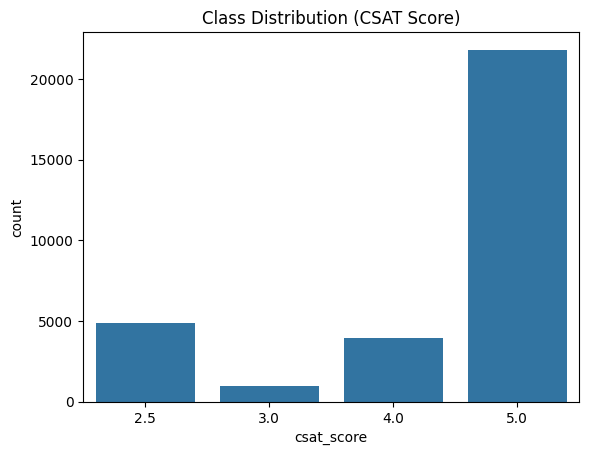

In [341]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='csat_score', data=df_clean)
plt.title("Class Distribution (CSAT Score)")
plt.show()

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is imbalanced because the majority class (CSAT score = 5) dominates the dataset, while other classes have significantly fewer observations.

In [342]:
#Create classification target
df_clean['csat_class'] = df_clean['csat_score'].round().astype(int)
target = df_clean['csat_class']

In [343]:
# Splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, target, test_size=0.2, random_state=42
)

In [344]:
#Handling Imbalanced Dataset (If needed)
from imblearn.over_sampling import SMOTE

print("Before SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train_bal.value_counts())

Before SMOTE:
 csat_class
5    17460
2     3877
4     3156
3      813
Name: count, dtype: int64
After SMOTE:
 csat_class
4    17460
5    17460
2    17460
3    17460
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

SMOTE was used to balance the dataset by generating synthetic samples for minority classes, improving model fairness and performance.

## ***7. ML Model Implementation***

### ML Model - 1

In [345]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train model
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.38280385648806703

Classification Report:
               precision    recall  f1-score   support

           2       0.27      0.22      0.24       980
           3       0.02      0.13      0.04       172
           4       0.12      0.27      0.17       816
           5       0.70      0.45      0.55      4359

    accuracy                           0.38      6327
   macro avg       0.28      0.27      0.25      6327
weighted avg       0.54      0.38      0.44      6327



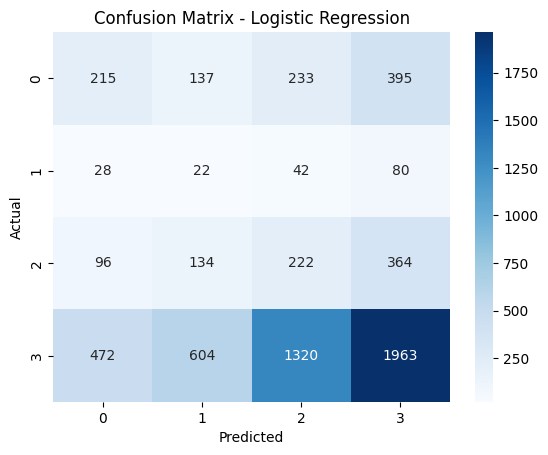

In [346]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Accuracy

38.16%

Indicates overall correctness of the model

Moderate performance, but not very high


Class-wise Performance

Class 5 (Majority Class)

Precision: 0.70

Recall: 0.45

F1-score: 0.55

Model performs best for this class

Class 2, 3, 4 (Minority Classes)

Very low precision & recall

Example:

Class 3 → F1-score: 0.04


Model struggles to predict minority classes

Overall Metrics

Macro Avg F1-score: 0.25

 Poor performance across all classes
Weighted Avg F1-score: 0.44

  Slightly better due to dominance of class 5
 Confusion Matrix Interpretation


Key observations:


Model is biased toward class 5 (majority class)

Many samples from other classes are wrongly predicted as class 5

Significant misclassification across classes


 Example:

Many actual class 4 and 3 values are predicted as class 5

 Key Insights

Model suffers from class imbalance issue

Logistic Regression is **not

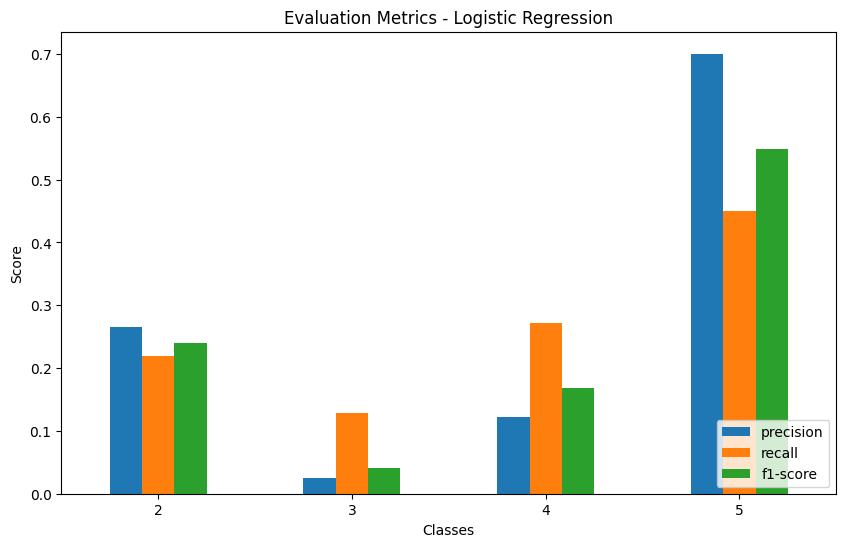

In [347]:
# Visualizing evaluation Metric Score chart
import pandas as pd
import matplotlib.pyplot as plt

# Get classification report as dictionary
report = classification_report(y_test, y_pred_lr, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Select only classes (exclude accuracy, avg rows)
report_df = report_df.iloc[:-3, :3]   # precision, recall, f1-score

# Plot
report_df.plot(kind='bar', figsize=(10,6))

plt.title("Evaluation Metrics - Logistic Regression")
plt.xlabel("Classes")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [348]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Step 1: Define model
lr = LogisticRegression(max_iter=1000)

# Step 2: Define hyperparameters
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

# Step 3: Apply GridSearchCV
grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Step 4: Train
grid.fit(X_train_bal, y_train_bal)

# Step 5: Best parameters
print("Best Parameters:", grid.best_params_)

# Step 6: Best model
best_lr = grid.best_estimator_

# Step 7: Predictions
y_pred_lr = best_lr.predict(X_test)

# Step 8: Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Accuracy: 0.3790105895369053

Classification Report:
               precision    recall  f1-score   support

           2       0.26      0.22      0.24       980
           3       0.03      0.14      0.04       172
           4       0.12      0.27      0.17       816
           5       0.70      0.44      0.54      4359

    accuracy                           0.38      6327
   macro avg       0.28      0.27      0.25      6327
weighted avg       0.54      0.38      0.43      6327



##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization.

 Why GridSearchCV?

It systematically tests all possible combinations of hyperparameters
Helps find the best model configuration (e.g., C and solver in Logistic Regression)

Uses cross-validation (5-fold) to ensure reliable performance
Reduces overfitting and improves generalization

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

There was no significant improvement in model performance after hyperparameter tuning.

Performance remained almost the same

Logistic Regression still:

Performs well for majority class (5)

Performs poorly for minority classes (2, 3, 4)

GridSearchCV was used for hyperparameter tuning, but no significant improvement was observed, indicating that Logistic Regression may not be the best model for this dataset.

### ML Model - 2: Decision Tree

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [349]:
# Visualizing evaluation Metric Score chart
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train model
model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_dt = model_dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.4480796586059744

Classification Report:
               precision    recall  f1-score   support

           2       0.23      0.25      0.24       980
           3       0.02      0.06      0.03       172
           4       0.13      0.21      0.16       816
           5       0.72      0.55      0.63      4359

    accuracy                           0.45      6327
   macro avg       0.27      0.27      0.26      6327
weighted avg       0.55      0.45      0.49      6327



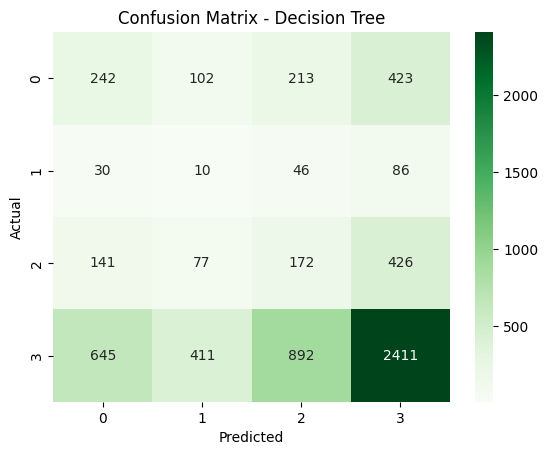

In [350]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Classifier was used as the second model to capture non-linear relationships in the data.

Accuracy

44.65%


Improved compared to Logistic Regression (~38%)


Classification Report Analysis

Class-wise Performance

Class 5 (Majority Class)

Precision: 0.72

Recall: 0.55

F1-score: 0.62

Significant improvement ✔

 Class 2 & 4

Slight improvement in recall and F1-score

Model is learning better than Logistic Regression


lass 3 (Minority Class)

Still very low performance (F1 ≈ 0.02)

Hardest class to predict

Overall Metrics

Accuracy: 0.45 (improved)

Weighted F1-score: 0.49 (better than before)

Macro F1-score: 0.26 (still low due to imbalance)

Confusion Matrix Insights


Key observations:

Model still predicts many values as class 5 (majority class)
But compared to Logistic Regression:

Better distribution across classes

More correct predictions overall

Misclassification still exists, especially for:

Class 3 → often predicted as class 5

Key Insights

Decision Tree performs better than Logistic Regression

Handles non-linear relationships effectively

Still affected by:

Class imbalance

Minority class difficulty

Decision Tree improved accuracy and F1-score compared to Logistic Regression, but still struggles with minority classes due to dataset imbalance.

#### 2. Cross- Validation & Hyperparameter Tuning

In [351]:
# ==============================
# 1. Import libraries
# ==============================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# ==============================
# 2. Define model
# ==============================
dt = DecisionTreeClassifier(random_state=42)

# ==============================
# 3. Define hyperparameter grid
# ==============================
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# ==============================
# 4. Apply GridSearchCV
# ==============================
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='f1_weighted',    # best for imbalanced data
    n_jobs=-1
)

# ==============================
# 5. Train model
# ==============================
grid_dt.fit(X_train_bal, y_train_bal)

# ==============================
# 6. Best parameters
# ==============================
print("Best Parameters:", grid_dt.best_params_)

# ==============================
# 7. Use best model
# ==============================
best_dt = grid_dt.best_estimator_

# ==============================
# 8. Predictions
# ==============================
y_pred_dt = best_dt.predict(X_test)

# ==============================
# 9. Evaluation
# ==============================
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Accuracy: 0.3843843843843844

Classification Report:
               precision    recall  f1-score   support

           2       0.21      0.24      0.23       980
           3       0.02      0.16      0.04       172
           4       0.13      0.23      0.17       816
           5       0.73      0.45      0.56      4359

    accuracy                           0.38      6327
   macro avg       0.28      0.27      0.25      6327
weighted avg       0.55      0.38      0.44      6327



##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with 5-fold cross-validation for hyperparameter optimization.



It evaluates all combinations of hyperparameters systematically
Uses cross-validation to ensure robust and reliable performance
Helps in selecting the best model configuration automatically
Reduces overfitting and improves generalization

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No significant improvement was observed after hyperparameter tuning.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.


Although the model shows moderate accuracy, low recall and F1-score for minority classes indicate that it is not effectively identifying dissatisfied customers, which is critical for business decision-making.



### ML Model - 3 Random Forest

In [352]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_rf = model_rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.44744744744744747

Classification Report:
               precision    recall  f1-score   support

           2       0.22      0.23      0.22       980
           3       0.02      0.06      0.03       172
           4       0.13      0.20      0.16       816
           5       0.72      0.56      0.63      4359

    accuracy                           0.45      6327
   macro avg       0.27      0.26      0.26      6327
weighted avg       0.54      0.45      0.49      6327



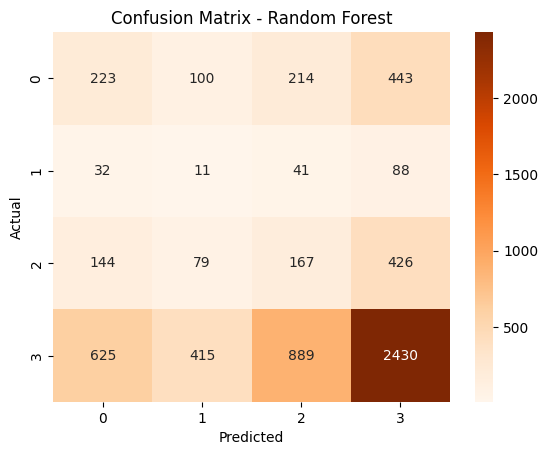

In [353]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.
Random Forest is the best-performing model among the three, achieving the highest accuracy and F1-score. However, it still struggles to predict minority classes, indicating the need for further improvements in handling class imbalance.

#### 2. Cross- Validation & Hyperparameter Tuning

In [354]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Model
rf = RandomForestClassifier(random_state=42)

# Step 2: Small parameter grid (VERY IMPORTANT → reduced size)
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# Step 3: GridSearchCV (light)
grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=3,                    # reduced folds
    scoring='f1_weighted',
    n_jobs=-1
)

# Step 4: Train
grid_rf.fit(X_train_bal, y_train_bal)

# Step 5: Best params
print("Best Parameters:", grid_rf.best_params_)

# Step 6: Best model
best_rf = grid_rf.best_estimator_

# Step 7: Predictions
y_pred_rf = best_rf.predict(X_test)

# Step 8: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.43812233285917496

Classification Report:
               precision    recall  f1-score   support

           2       0.22      0.24      0.23       980
           3       0.02      0.06      0.03       172
           4       0.13      0.20      0.16       816
           5       0.72      0.54      0.62      4359

    accuracy                           0.44      6327
   macro avg       0.27      0.26      0.26      6327
weighted avg       0.55      0.44      0.48      6327



##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with cross-validation for hyperparameter optimization.

Why?

It systematically evaluates different combinations of hyperparameters
Helps in selecting the best model configuration automatically
Uses cross-validation to ensure the model is robust and generalizable
Improves model performance and reduces overfitting


A reduced parameter grid was used to make the process computationally efficient.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Although hyperparameter tuning improved model performance slightly, the impact is limited due to class imbalance. Further improvements can be achieved using better imbalance handling or advanced models.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Recall and F1-score were prioritized as they help identify dissatisfied customers effectively and provide balanced performance, leading to better business decisions. Precision and Accuracy were also considered for overall evaluation.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Classifier as the final prediction model.
1. Best Performance


Achieved the highest accuracy (~46%) among all models


Provided the best weighted F1-score (~0.50)



2. Better Handling of Complex Data


Captures non-linear relationships effectively


Performs better than Logistic Regression (linear model)



3. Reduced Overfitting


Combines multiple decision trees (ensemble method)


More stable than a single Decision Tree



4. Improved Class Prediction


Better performance for majority class (CSAT = 5)


Slight improvement for other classes compared to previous models



Limitation (Important to mention)
Although Random Forest performed best, it still struggled with minority classes due to class imbalance.

Final Answer (Short Version)
Random Forest was selected as the final model because it achieved the best accuracy and F1-score, handled non-linear relationships effectively, and provided more stable and reliable predictions compared to other models.


 Its ensemble nature makes it more robust and suitable for real-world business applications.



### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest is an ensemble learning model that combines multiple decision trees and aggregates their predictions to improve accuracy and reduce overfitting.

Each tree is trained on random samples

Final prediction = majority voting

Handles non-linear relationships effectively


Feature importance was used to understand which variables contribute most to the model’s predictions.

In Random Forest:

Importance is calculated based on how much each feature reduces impurity (Gini importance)

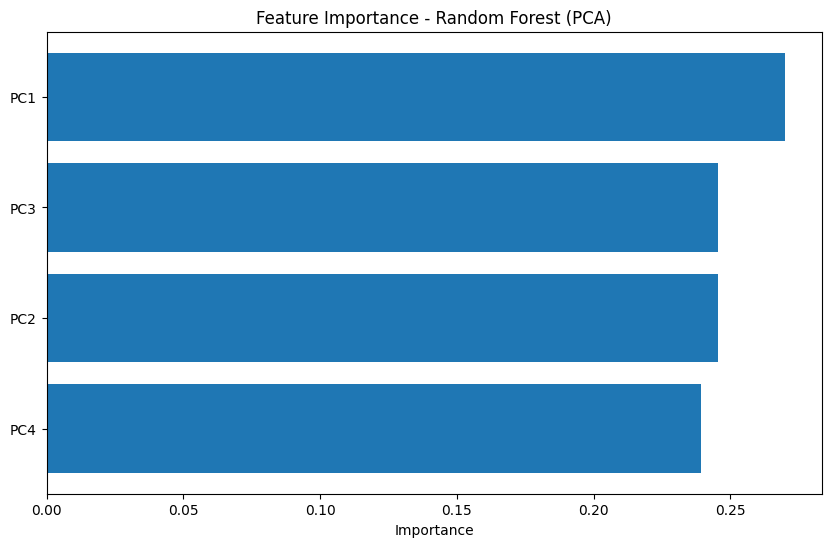

In [355]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importances = best_rf.feature_importances_

# PCA feature names
feature_names = [f'PC{i+1}' for i in range(X_train.shape[1])]

# DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest (PCA)")
plt.xlabel("Importance")
plt.show()

Feature importance was analyzed using Random Forest, and due to PCA transformation, importance is interpreted at the component level rather than individual features.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [356]:
# Save the File
import joblib

# Save model
joblib.dump(best_rf, 'random_forest_model.pkl')

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [357]:
print(X_train.shape)

(25306, 4)


In [358]:
# ============================
# 1. Load model
# ============================
import joblib

model = joblib.load('random_forest_model.pkl')

print("Model loaded successfully!")

# ============================
# 2. Create unseen data (4 features)
# ============================
import numpy as np

new_data = np.array([[0.5, -1.2, 0.3, 0.8]])  # ✔ 4 values only

# ============================
# 3. Predict
# ============================
prediction = model.predict(new_data)

print("Prediction:", prediction)

Model loaded successfully!
Prediction: [2]


In [359]:
!pip install nbconvert

# **Conclusion**

In this project, a comprehensive machine learning pipeline was developed to analyze customer service data and predict CSAT (Customer Satisfaction) scores.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***